In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!unzip -o "/content/drive/MyDrive/SeedDataset2/SeedDataset.zip" -d /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/SeedDataset/test/custard_undamaged/Custard4_good_25.jpg  
  inflating: /content/SeedDataset/test/custard_undamaged/Custard4_good_30.jpg  
  inflating: /content/SeedDataset/test/custard_undamaged/Custard4_good_35.jpg  
  inflating: /content/SeedDataset/test/custard_undamaged/Custard4_good_40.jpg  
  inflating: /content/SeedDataset/test/custard_undamaged/Custard4_good_45.jpg  
  inflating: /content/SeedDataset/test/custard_undamaged/Custard4_good_5.jpg  
  inflating: /content/SeedDataset/test/custard_undamaged/Custard4_good_50.jpg  
  inflating: /content/SeedDataset/test/custard_undamaged/Custard4_good_55.jpg  
  inflating: /content/SeedDataset/test/custard_undamaged/Custard4_good_60.jpg  
  inflating: /content/SeedDataset/test/custard_undamaged/Custard4_good_65.jpg  
  inflating: /content/SeedDataset/test/custard_undamaged/Custard4_good_70.jpg  
  inflating: /content/SeedDataset/test/custard_undamaged/Custard4_good

In [ ]:
import os
print(os.listdir("/content/SeedDataset"))

['train', 'test']


In [ ]:
print(os.listdir("/content/SeedDataset/train"))

['apple_damaged', 'custard_damaged', 'apple_undamaged', 'custard_undamaged', 'bittergourd_undamaged', 'mosambi_damaged', 'mosambi_undamaged', 'bittergourd_damaged']


In [ ]:
!pip install tensorflow opencv-python matplotlib --quiet

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import numpy as np
import cv2

In [ ]:
train_path = '/content/SeedDataset/train'
test_path  = '/content/SeedDataset/test'

# Normalize and slightly augment (rotate, zoom) training images
train_gen = ImageDataGenerator(
    rescale=1./255,              # normalize pixel values (0–255 → 0–1)
    rotation_range=15,           # small random rotation
    zoom_range=0.1,              # small random zoom
    horizontal_flip=True,         # flip images randomly for variation
    validation_split=0.2   # ⭐ ADD THIS
)

test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',   # CHANGED
    subset='training'
)

val_data = train_gen.flow_from_directory(
    train_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

test_data = test_gen.flow_from_directory(
    test_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',   # CHANGED
    shuffle=False
)

class_indices = train_data.class_indices
label_map = {v: k for k, v in class_indices.items()}
print("Class Mapping:", label_map)

Found 3688 images belonging to 8 classes.
Found 920 images belonging to 8 classes.
Found 1152 images belonging to 8 classes.
Class Mapping: {0: 'apple_damaged', 1: 'apple_undamaged', 2: 'bittergourd_damaged', 3: 'bittergourd_undamaged', 4: 'custard_damaged', 5: 'custard_undamaged', 6: 'mosambi_damaged', 7: 'mosambi_undamaged'}


In [ ]:
print(train_data.class_indices)

{'apple_damaged': 0, 'apple_undamaged': 1, 'bittergourd_damaged': 2, 'bittergourd_undamaged': 3, 'custard_damaged': 4, 'custard_undamaged': 5, 'mosambi_damaged': 6, 'mosambi_undamaged': 7}


In [ ]:
label_map = train_data.class_indices
labels = [None] * len(label_map)

for name, index in label_map.items():
    labels[index] = name

print(labels)

['apple_damaged', 'apple_undamaged', 'bittergourd_damaged', 'bittergourd_undamaged', 'custard_damaged', 'custard_undamaged', 'mosambi_damaged', 'mosambi_undamaged']


In [ ]:
model = Sequential([

    # Block 1
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Block 2
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Block 3
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Block 4
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Classification
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(8, activation='softmax')   # 8 CLASSES
])

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833,224 (3.18 MB)

 Trainable params: 832,520 (3.18 MB)

 Non-trainable params: 704 (2.75 KB)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=25,
    callbacks=[early_stop, lr_reduce]
)

Epoch 1/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 211s 2s/step - accuracy: 0.7448 - loss: 0.6654 - val_accuracy: 0.0630 - val_loss: 3.0892 - learning_rate: 1.0000e-04
Epoch 2/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 206s 2s/step - accuracy: 0.8826 - loss: 0.3264 - val_accuracy: 0.0663 - val_loss: 4.0106 - learning_rate: 1.0000e-04
Epoch 3/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 208s 2s/step - accuracy: 0.9352 - loss: 0.1889 - val_accuracy: 0.1326 - val_loss: 3.6184 - learning_rate: 1.0000e-04
Epoch 4/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 215s 2s/step - accuracy: 0.9566 - loss: 0.1225 - val_accuracy: 0.3837 - val_loss: 2.7745 - learning_rate: 1.0000e-04
Epoch 5/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 214s 2s/step - accuracy: 0.9666 - loss: 0.0982 - val_accuracy: 0.7228 - val_loss: 0.7536 - learning_rate: 1.0000e-04
Epoch 6/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 216s 2s/step - accuracy: 0.9810 - loss: 0.0658 - val_accuracy: 0.8598 - val_loss: 0.3652 - learning_rate: 1.0000e-04
Epoch 7/25
116/116 ━━━━━━━━━━━━━━━━━━━━ 208s 2s/step - acc


Training Accuracy: 0.9943058490753174
Validation Accuracy: 0.823913037776947
36/36 ━━━━━━━━━━━━━━━━━━━━ 13s 354ms/step - accuracy: 0.9722 - loss: 0.0988

Test Accuracy: 0.9722222089767456
36/36 ━━━━━━━━━━━━━━━━━━━━ 13s 352ms/step

Confusion Matrix:
 [[144   0   0   0   0   0   0   0]
 [ 12 130   0   0   0   0   2   0]
 [  0   0 144   0   0   0   0   0]
 [  0   0   2 131   0   0   0  11]
 [  0   0   0   0 144   0   0   0]
 [  0   0   0   0   4 140   0   0]
 [  0   0   1   0   0   0 143   0]
 [  0   0   0   0   0   0   0 144]]

Classification Report:
                        precision    recall  f1-score   support

        apple_damaged       0.92      1.00      0.96       144
      apple_undamaged       1.00      0.90      0.95       144
  bittergourd_damaged       0.98      1.00      0.99       144
bittergourd_undamaged       1.00      0.91      0.95       144
      custard_damaged       0.97      1.00      0.99       144
    custard_undamaged       1.00      0.97      0.99       144
 

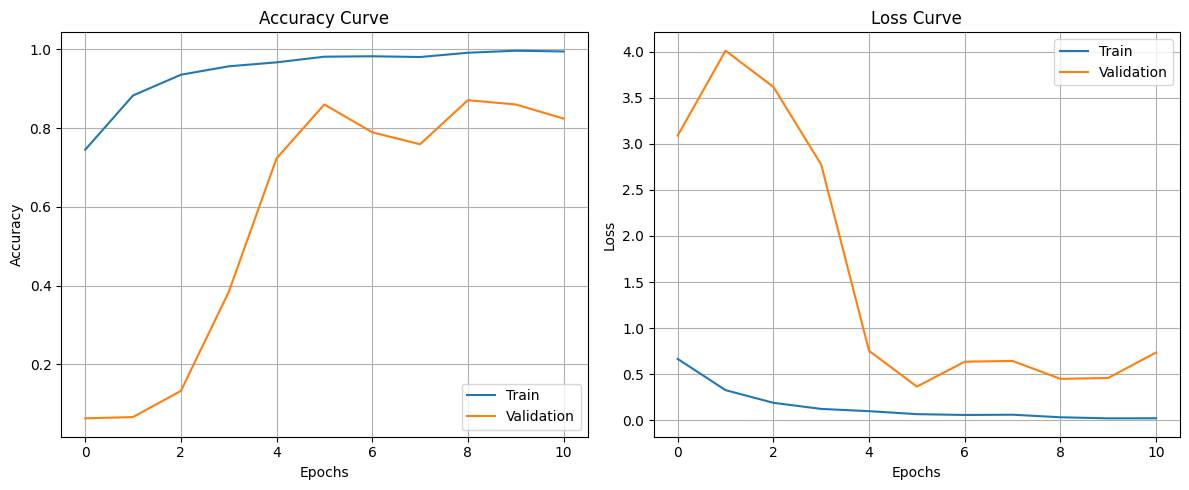

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    precision_score, recall_score,
    f1_score, classification_report
)

# ==============================
# 6. TRAIN & VALIDATION RESULTS
# ==============================
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print("\nTraining Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)

# ==============================
# 7. TEST ACCURACY
# ==============================
test_loss, test_acc = model.evaluate(test_data)

print("\nTest Accuracy:", test_acc)

# ==============================
# 8. TEST PREDICTIONS
# ==============================
test_data.reset()

y_true = test_data.classes
y_prob = model.predict(test_data)
y_pred = np.argmax(y_prob, axis=1)

# ==============================
# 9. CONFUSION MATRIX
# ==============================
cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:\n", cm)

# ==============================
# 10. CLASSIFICATION REPORT
# ==============================
print("\nClassification Report:\n",
      classification_report(
          y_true,
          y_pred,
          target_names=list(test_data.class_indices.keys())
      ))

# ==============================
# 11. METRICS (MACRO AVERAGE)
# ==============================
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

print("\nAccuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# ==============================
# 12. ACCURACY & LOSS GRAPHS
# ==============================
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

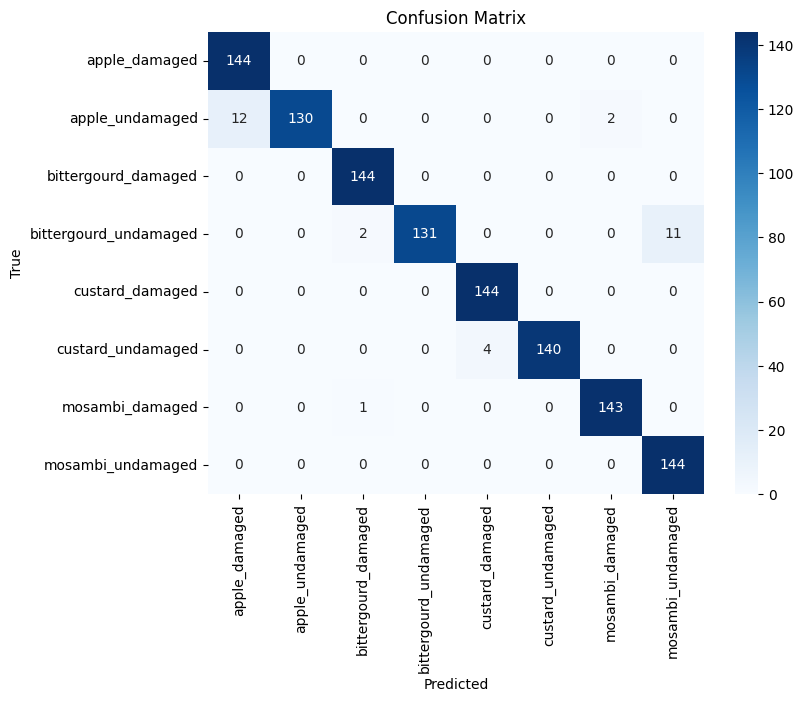

In [ ]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(test_data.class_indices.keys()),
            yticklabels=list(test_data.class_indices.keys()))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

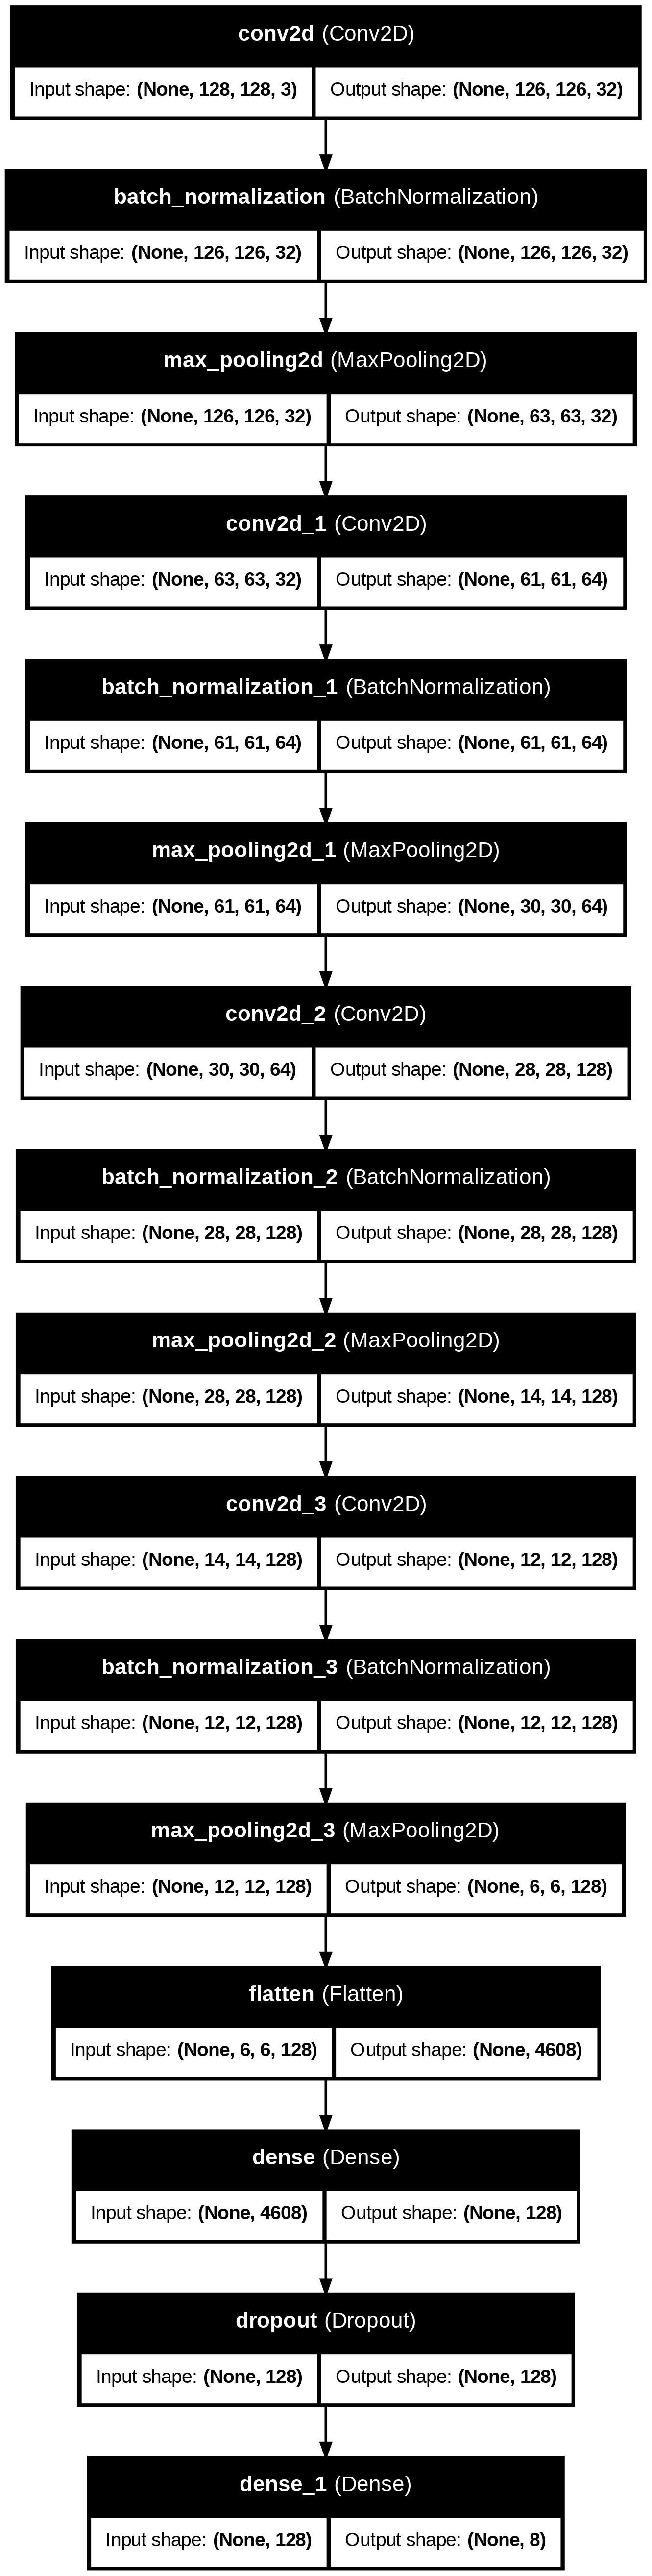

In [ ]:
from tensorflow.keras.utils import plot_model

plot_model(
    model,
    to_file='cnn_architecture_new.png',
    show_shapes=True,
    show_layer_names=True,
    expand_nested=True,
    dpi=200
)

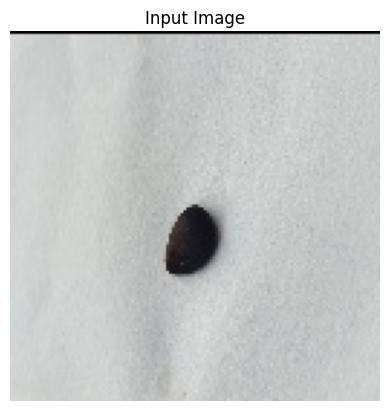

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step


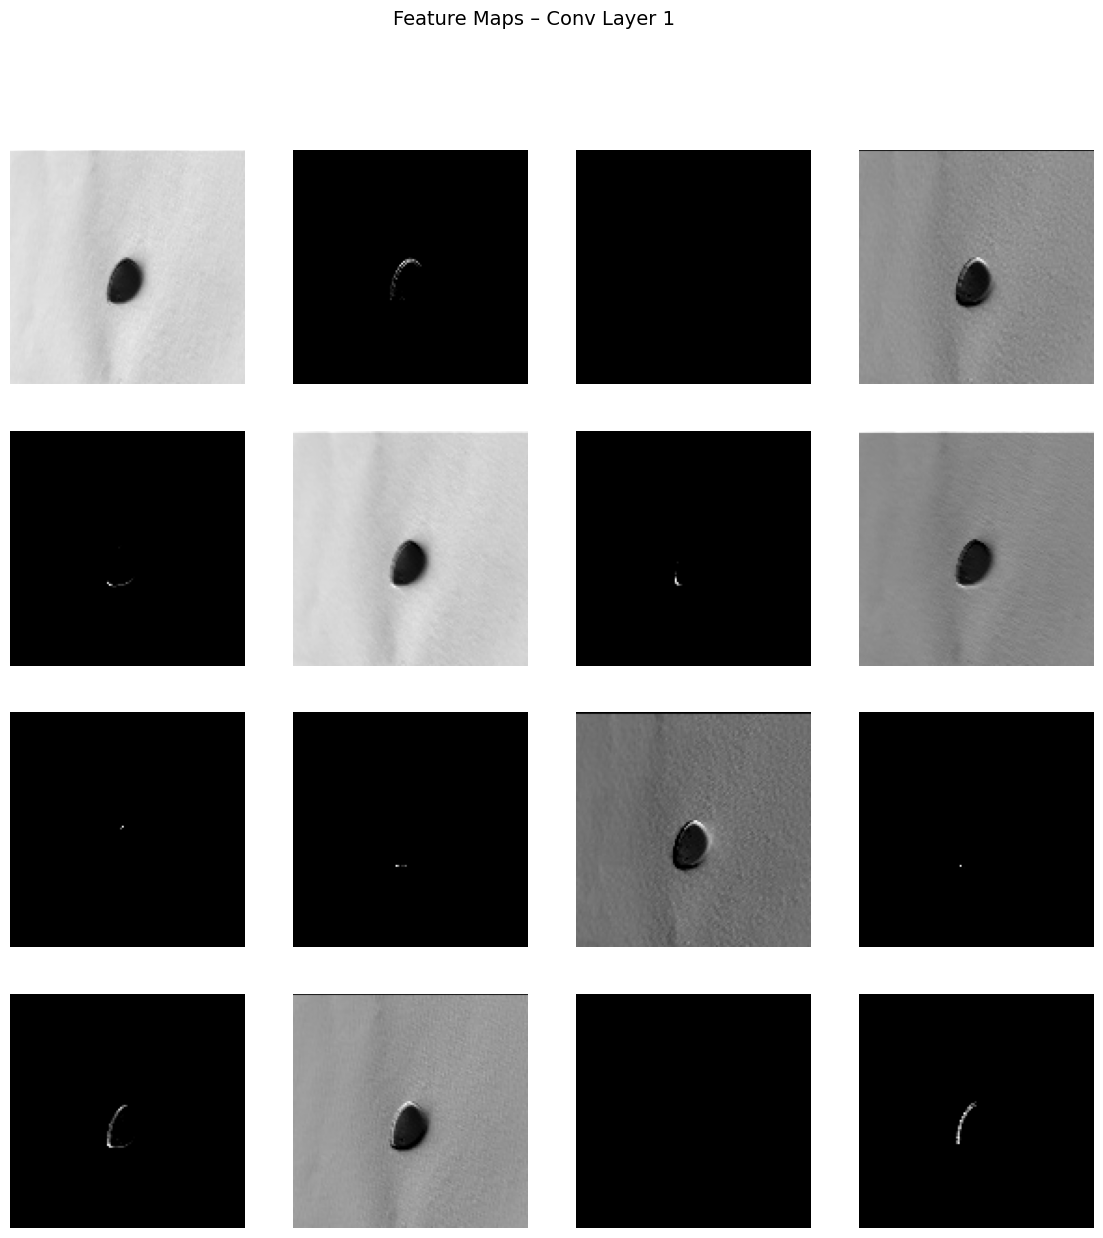

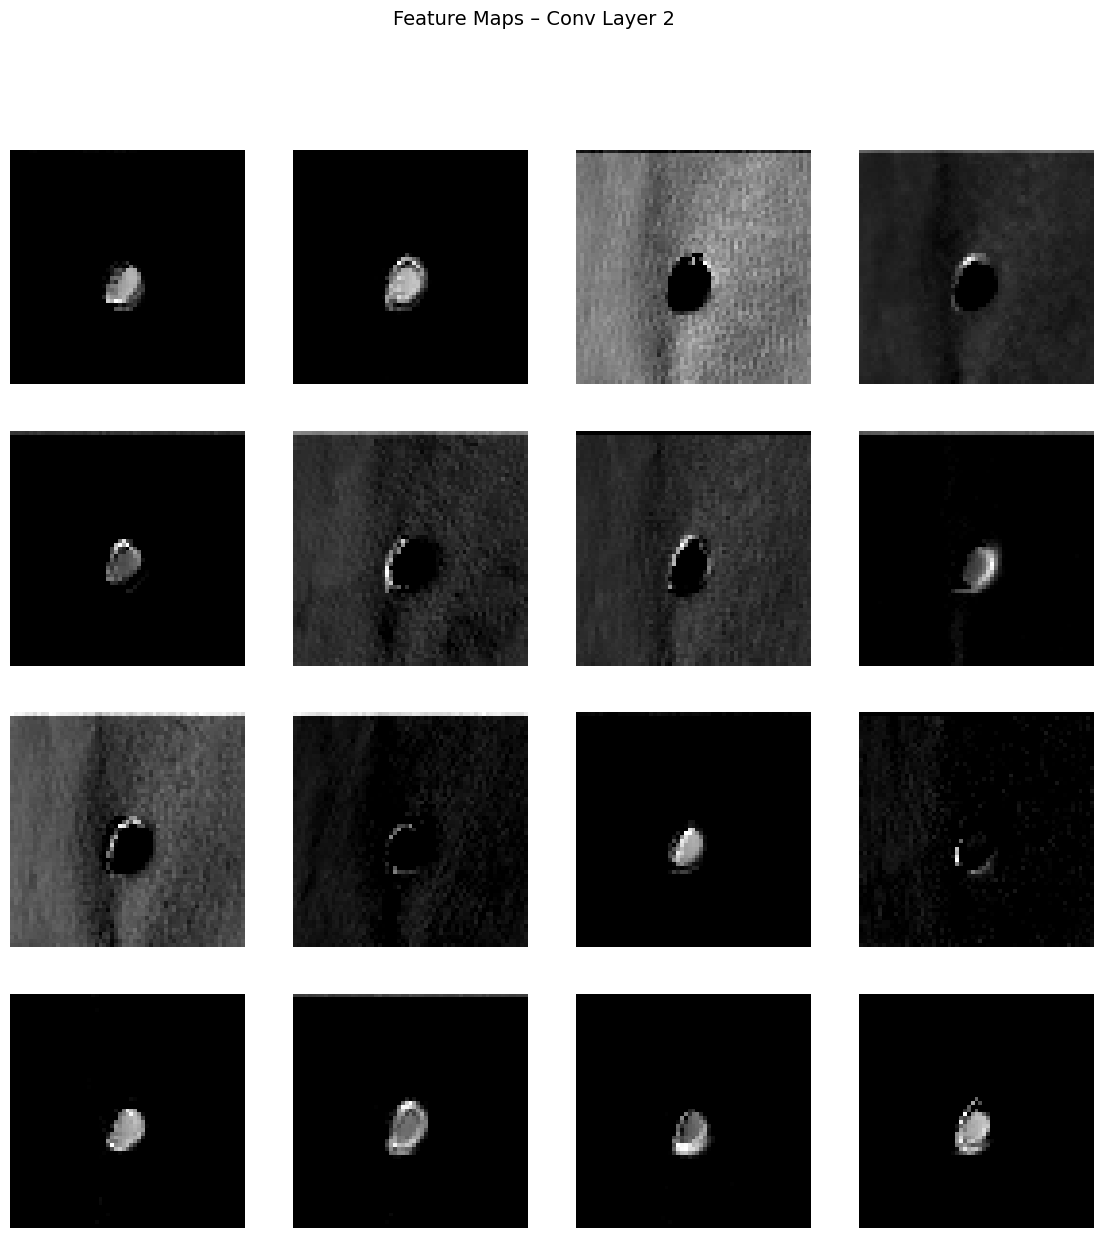

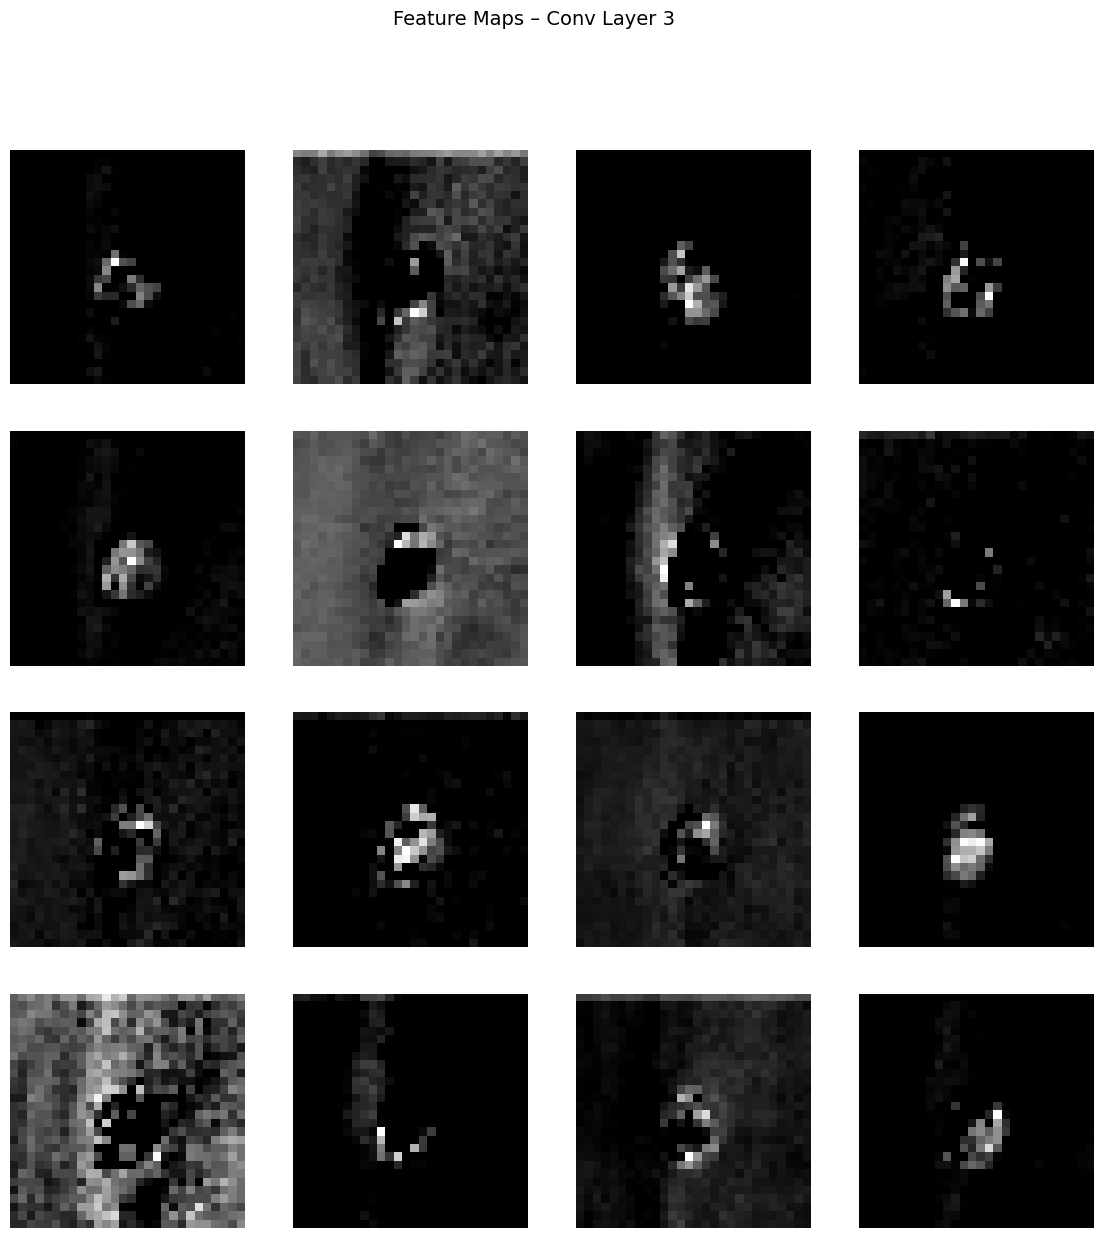

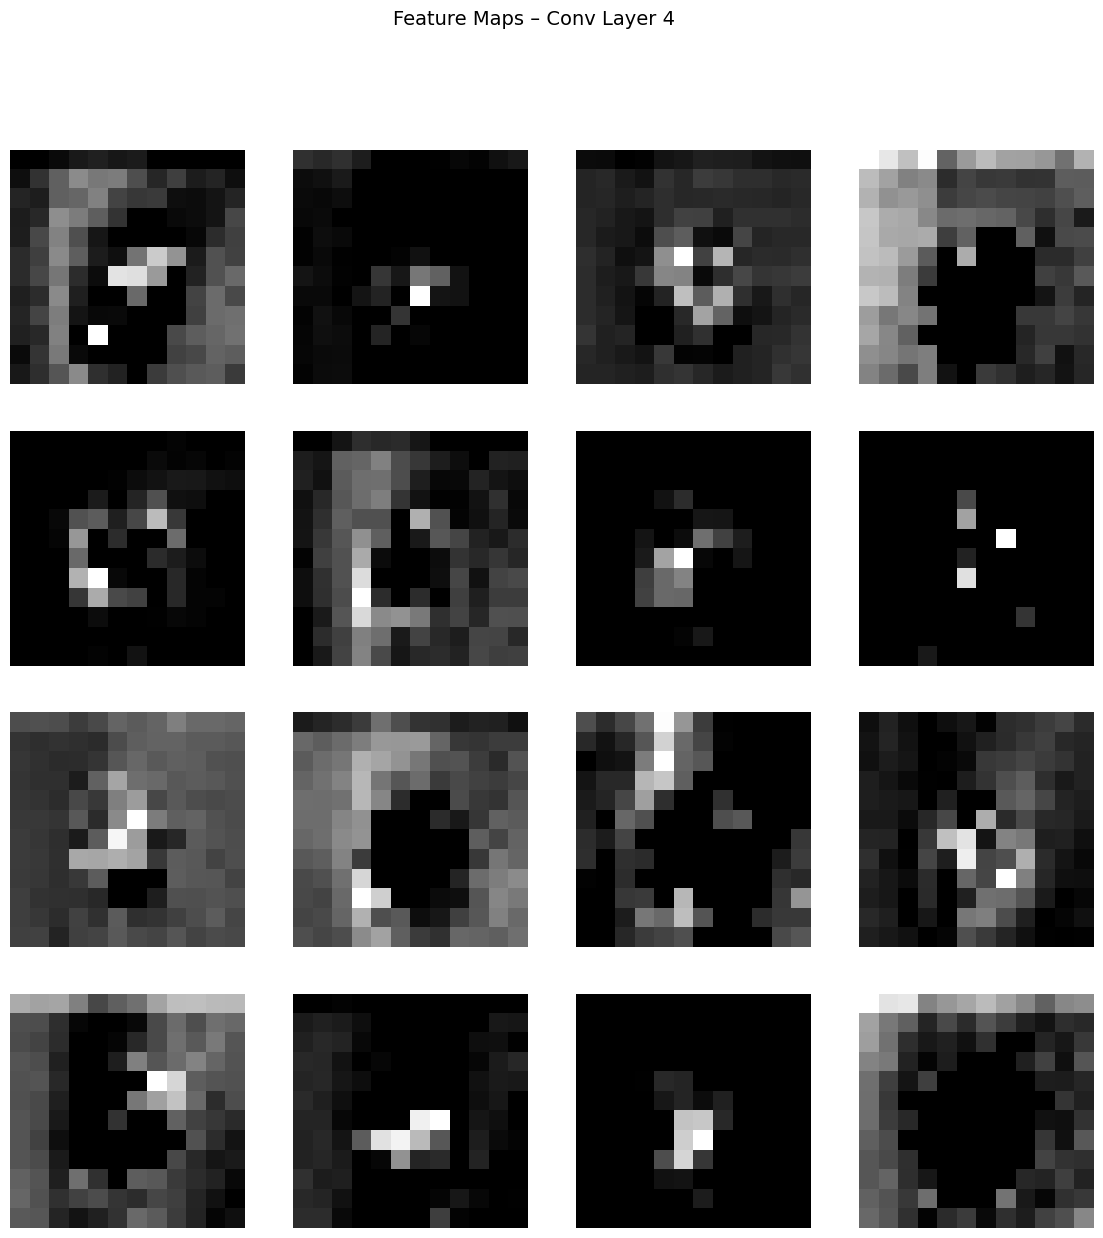

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D

# Reset generator
test_data.reset()

# Take one sample image
sample_img_batch, _ = next(test_data)
sample_img = sample_img_batch[0]
sample_input = np.expand_dims(sample_img, axis=0)

# Show input image
plt.imshow(sample_img)
plt.title("Input Image")
plt.axis('off')
plt.show()

# IMPORTANT: force model to build input
_ = model.predict(sample_input)

# Get Conv layers
conv_layers = [layer for layer in model.layers if isinstance(layer, Conv2D)]
conv_outputs = [layer.output for layer in conv_layers]

# Create feature extraction model
feature_model = Model(
    inputs=model.layers[0].input,   # SAFEST way
    outputs=conv_outputs
)

# Get feature maps
feature_maps = feature_model.predict(sample_input)

# Plot feature maps
for i, fmap in enumerate(feature_maps):
    plt.figure(figsize=(14, 14))
    plt.suptitle(f"Feature Maps – Conv Layer {i+1}", fontsize=14)

    for j in range(min(16, fmap.shape[-1])):
        plt.subplot(4, 4, j+1)
        plt.imshow(fmap[0, :, :, j], cmap='gray')
        plt.axis('off')

    plt.show()

In [ ]:
model.save('seed_multiclass_cnn_model2.h5')
print("✅ Model saved successfully!")

✅ Model saved successfully!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

model.save('/content/drive/MyDrive/SeedDataset2/seed_health_cnn_model2.keras')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
os.listdir('/content/drive/MyDrive/SeedDataset2')

['SeedDataset.zip',
 'seed_health_cnn_model.keras',
 'seed_health_cnn_model2.keras']

In [ ]:
from tensorflow.keras.models import load_model
model = load_model('seed_multiclass_cnn_model2.h5')
print("✅ Model loaded successfully!")

# Just run one evaluation on test data (optional)
model.evaluate(test_data, verbose=0)

✅ Model loaded successfully!


[0.09883364289999008, 0.9722222089767456]

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from tensorflow.keras.models import load_model
model = load_model('/content/drive/MyDrive/SeedDataset2/seed_health_cnn_model2.keras')

print("✅ Model loaded successfully!")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model loaded successfully!


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 22 variables whereas the saved optimizer has 42 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
image_path = list(uploaded.keys())[0]

# Read & preprocess image
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (128, 128))
img_normalized = img_resized / 255.0
img_reshaped = np.expand_dims(img_normalized, axis=0)

In [ ]:
# Predict
probs = model.predict(img_reshaped)[0]
pred_index = np.argmax(probs)
accuracy = probs[pred_index] * 100

# Get full label (example: apple_damaged)
full_label = label_map[pred_index]

# Split fruit & condition
fruit_name, condition = full_label.split('_')

# Capitalize nicely
fruit_name = fruit_name.capitalize()
condition = condition.capitalize()

print(f"🍎 Fruit Type: {fruit_name}")
print(f"⚠️ Condition: {condition}")
print(f"📊 Accuracy: {accuracy:.2f}%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
🍎 Fruit Type: Bittergourd
⚠️ Condition: Damaged
📊 Accuracy: 100.00%


Saving BitterGourd8_good_72.jpg to BitterGourd8_good_72.jpg


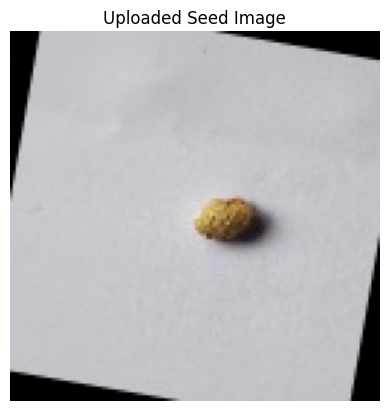


====== RESULT ======
🍎 Fruit Type : Bittergourd
⚠️ Condition  : Undamaged
📊 Confidence : 99.93%

Class Probabilities:
apple_damaged : 0.0000
apple_undamaged : 0.0000
bittergourd_damaged : 0.0000
bittergourd_undamaged : 0.9993
custard_damaged : 0.0000
custard_undamaged : 0.0000
mosambi_damaged : 0.0000
mosambi_undamaged : 0.0007


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# ==============================
# UPLOAD IMAGE
# ==============================
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# ==============================
# READ IMAGE
# ==============================
img = cv2.imread(image_path)

if img is None:
    raise ValueError("❌ Error: Image not loaded properly")

# Convert BGR → RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# ==============================
# PREPROCESS
# ==============================
img_resized = cv2.resize(img_rgb, (128, 128))
img_normalized = img_resized / 255.0
img_input = np.expand_dims(img_normalized, axis=0)

# ==============================
# SHOW IMAGE
# ==============================
plt.imshow(img_rgb)
plt.title("Uploaded Seed Image")
plt.axis('off')
plt.show()

# ==============================
# PREDICTION
# ==============================
probs = model.predict(img_input, verbose=0)[0]

pred_index = np.argmax(probs)
confidence = probs[pred_index] * 100

# ==============================
# LABEL MAPPING (SAFE)
# ==============================
# Ensure correct mapping
class_labels = {v: k for k, v in train_data.class_indices.items()}

full_label = class_labels[pred_index]

# ==============================
# SPLIT LABEL
# ==============================
try:
    fruit_name, condition = full_label.split('_')
except:
    fruit_name = full_label
    condition = "Unknown"

fruit_name = fruit_name.capitalize()
condition = condition.capitalize()

# ==============================
# OUTPUT
# ==============================
print("\n====== RESULT ======")
print(f"🍎 Fruit Type : {fruit_name}")
print(f"⚠️ Condition  : {condition}")
print(f"📊 Accuracy : {confidence:.2f}%")

# Show full probabilities (VERY USEFUL)
print("\nClass Probabilities:")
for i, p in enumerate(probs):
    print(f"{class_labels[i]} : {p:.4f}")